First 5 rows (BMI and Progression):
        BMI  Progression
0  0.061696        151.0
1 -0.051474         75.0
2  0.044451        141.0
3 -0.011595        206.0
4 -0.036385        135.0

BMI range: -0.09027529589850945 to 0.17055522598064407
Progression range: 25.0 to 346.0

Training samples: 353
Testing samples : 89

Learned equation:
Progression = 998.58 × BMI + 152.00

Model performance on test data:
Mean Squared Error (MSE)  : 4061.83
Root Mean Squared Error   : 63.73
R² score                  : 0.233  (closer to 1 = better)


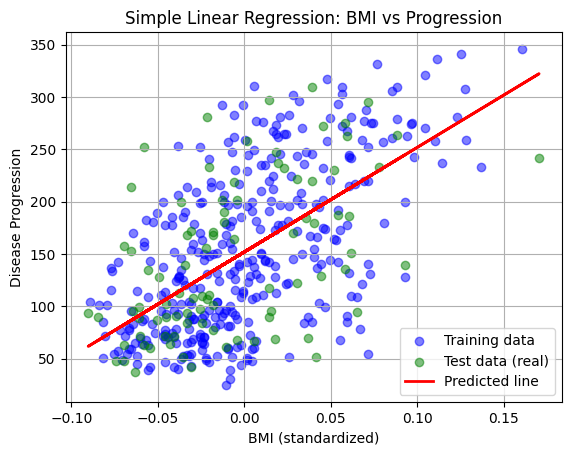

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target


X_bmi = X[:, 2].reshape(-1, 1)

df = pd.DataFrame(X_bmi, columns=['BMI'])
df['Progression'] = y
print("First 5 rows (BMI and Progression):")
print(df.head())

print("\nBMI range:", df['BMI'].min(), "to", df['BMI'].max())
print("Progression range:", df['Progression'].min(), "to", df['Progression'].max())

X_train, X_test, y_train, y_test = train_test_split(
    X_bmi, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

model = LinearRegression()
model.fit(X_train, y_train)


print("\nLearned equation:")
print(f"Progression = {model.coef_[0]:.2f} × BMI + {model.intercept_:.2f}")
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\nModel performance on test data:")
print(f"Mean Squared Error (MSE)  : {mse:.2f}")
print(f"Root Mean Squared Error   : {rmse:.2f}")
print(f"R² score                  : {r2:.3f}  (closer to 1 = better)")

plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test data (real)')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted line')

plt.xlabel('BMI (standardized)')
plt.ylabel('Disease Progression')
plt.title('Simple Linear Regression: BMI vs Progression')
plt.legend()
plt.grid(True)
plt.show()